# 🎓 BCS407 – Artificial Intelligence
## Project: AI-Based Smart Campus Safety Detection System
### Model: YOLOv8 | Theme: Campus Safety Monitoring
**Classes:** Wet Floor Signs · Fire Alarms · Emergency Exits · Safety Helmets

---
> **Before running:** Go to `Runtime > Change runtime type > Hardware accelerator = GPU (T4)`

## Step 0 — Verify GPU

In [6]:
import torch, subprocess, sys
if torch.cuda.is_available():
    try:
        subprocess.run(["nvidia-smi"])
    except Exception as e:
        print('nvidia-smi not available:', e)
else:
    print('CUDA not available; using CPU.')

## Step 1 — Install Dependencies

In [7]:
import sys, subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ultralytics', 'roboflow'])
import ultralytics
ultralytics.checks()

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.2/112.6 GB disk)


## Step 2 — Create directory for saving (for saving weights)

In [8]:
import os
# Local save directory (will be created in current working directory)
SAVE_DIR = os.path.join(os.getcwd(), 'BCS407_SafetyDetection')
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save directory ready: {SAVE_DIR}")

Save directory ready: /content/BCS407_SafetyDetection


## Step 3 — Download Dataset from Roboflow

> **Instructions:**
> 1. Go to your merged Roboflow project
> 2. Click **Export Dataset** → Format: **YOLOv8** → **Show Download Code**
> 3. Copy your API key and project details below
> 4. Replace the placeholder values (`YOUR_API_KEY`, `YOUR_WORKSPACE`, `YOUR_PROJECT`, `YOUR_VERSION`)

In [9]:
from roboflow import Roboflow

# !pip install roboflow


# ========================================================
# REPLACE THESE WITH YOUR ACTUAL ROBOFLOW DETAILS
# ========================================================
API_KEY      = "YOUR_API_KEY_HERE"       # From Roboflow account settings
WORKSPACE    = "mohammads-workspace-ervg9"     # Your Roboflow workspace name
PROJECT_NAME = "bcs_407-project-aui6o"       # Your merged project name
VERSION      = 1                    # Dataset version number
# ========================================================

rf = Roboflow(api_key=API_KEY)
project = rf.workspace(WORKSPACE).project(PROJECT_NAME)
dataset = project.version(VERSION).download("yolov8")

print(f"\nDataset downloaded to: {dataset.location}")
DATASET_PATH = dataset.location

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to BCS_407-Project-1 in yolov8:: 100%|██████████| 4142/4142 [00:01<00:00, 3262.14it/s]


Dataset downloaded to: /content/BCS_407-Project-1


## Step 4 — Explore & Verify the Dataset

In [10]:
import os
import yaml
from pathlib import Path

# Read the data.yaml file
yaml_path = os.path.join(DATASET_PATH, 'data.yaml')
with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

print('='*50)
print('DATASET CONFIGURATION')
print('='*50)
print(f"Number of classes : {data_config['nc']}")
print(f"Class names       : {data_config['names']}")
print()

# Count images per split
for split in ['train', 'valid', 'test']:
    split_path = Path(DATASET_PATH) / split / 'images'
    if split_path.exists():
        count = len(list(split_path.glob('*')))
        print(f"{split:10s} images: {count}")

print('='*50)

DATASET CONFIGURATION
Number of classes : 4
Class names       : ['Exit', 'Fire alarm', 'Wet Floor Sign', 'industrial-safety-helmet']

train      images: 1655
valid      images: 207
test       images: 207


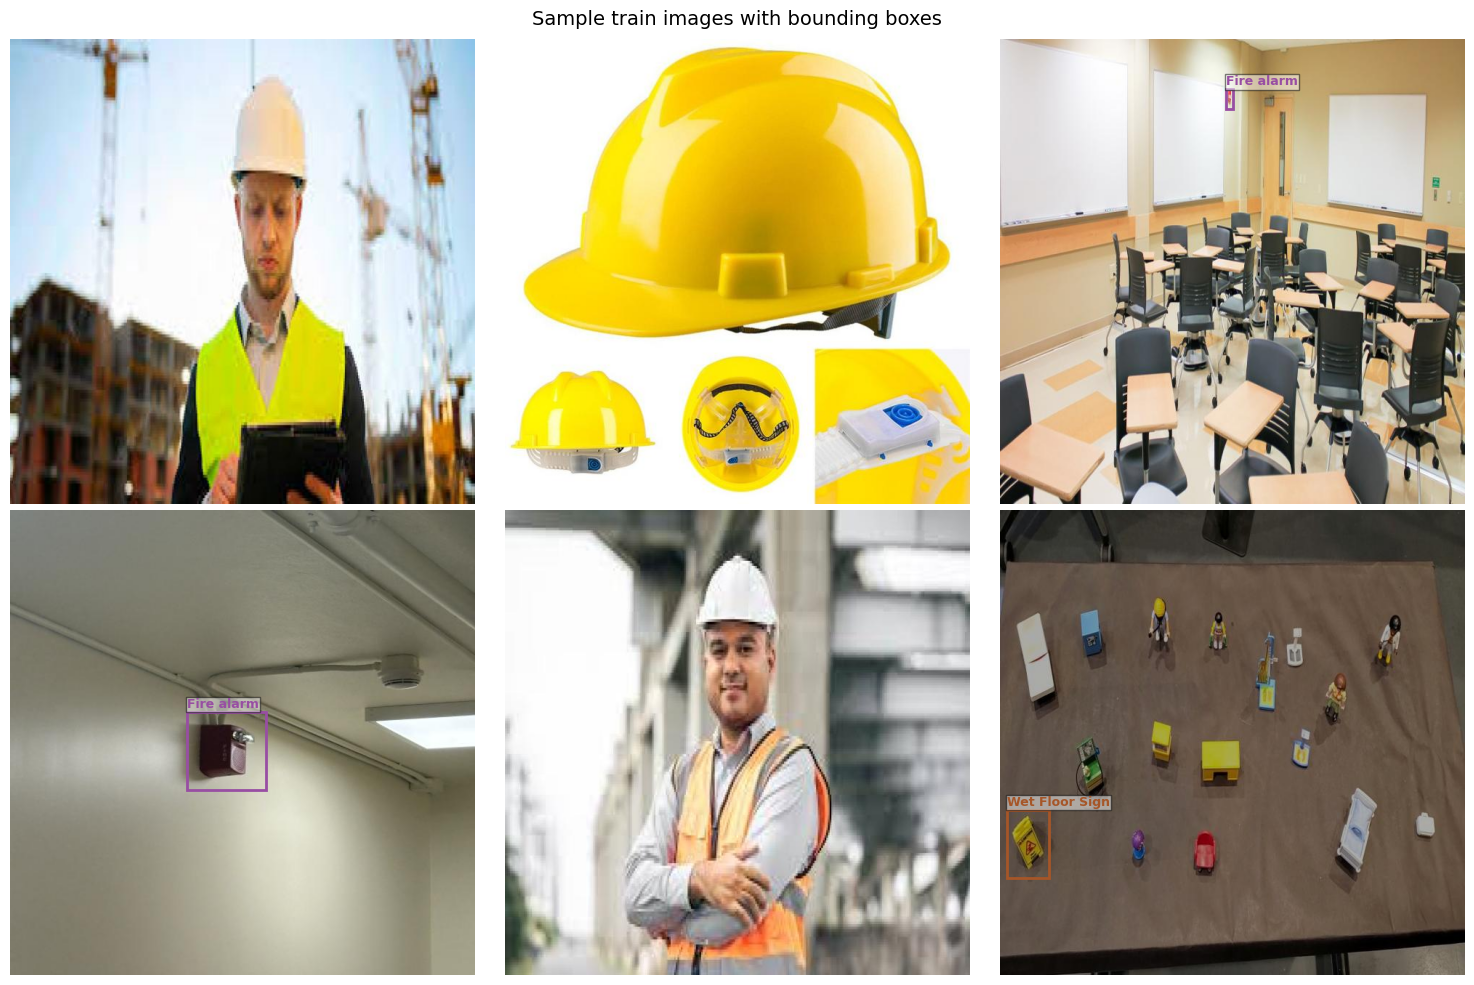

Saved sample annotations to: /content/BCS407_SafetyDetection/sample_annotations.png


In [11]:
import os
import random
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from pathlib import Path
import yaml

def visualize_sample(dataset_path, split='train', n=6):
    images_dir = Path(dataset_path) / split / 'images'
    labels_dir = Path(dataset_path) / split / 'labels'
    image_files = list(images_dir.glob('*'))
    sample = random.sample(image_files, min(n, len(image_files)))

    with open(Path(dataset_path) / 'data.yaml') as f:
        cfg = yaml.safe_load(f)
    class_names = cfg['names']
    colors = plt.cm.Set1(np.linspace(0, 1, len(class_names)))

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f'Sample {split} images with bounding boxes', fontsize=14)

    for ax, img_path in zip(axes.flatten(), sample):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        ax.imshow(img)

        lbl_path = labels_dir / (img_path.stem + '.txt')
        if lbl_path.exists():
            with open(lbl_path) as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cls, cx, cy, bw, bh = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                        x1 = (cx - bw/2) * w
                        y1 = (cy - bh/2) * h
                        rect = patches.Rectangle((x1, y1), bw*w, bh*h,
                                                  linewidth=2, edgecolor=colors[cls % len(colors)], facecolor='none')
                        ax.add_patch(rect)
                        ax.text(x1, y1-5, class_names[cls], color=colors[cls % len(colors)],
                                fontsize=9, fontweight='bold', bbox=dict(facecolor='white', alpha=0.5, pad=1))
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'sample_annotations.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved sample annotations to: {os.path.join(SAVE_DIR,'sample_annotations.png')}")

visualize_sample(DATASET_PATH)

## Step 5 — Train YOLOv8

**Model size options:**
| Model | Speed | Accuracy | Params |
|-------|-------|----------|--------|
| `yolov8n.pt` | Fastest | Lowest | 3.2M |
| `yolov8s.pt` | Fast | Good | 11.2M |
| `yolov8m.pt` | Medium | Better | 25.9M |
| `yolov8l.pt` | Slow | High | 43.7M |

> **Recommendation for this project:** Use `yolov8s.pt` — good balance of speed and accuracy on Colab T4 GPU.

In [12]:
from ultralytics import YOLO
import torch
# Detect device: GPU index (0) if available, otherwise 'cpu'
DEVICE = 0 if torch.cuda.is_available() else 'cpu'
PROJECT_DIR = os.path.join('runs', 'detect')
# Load pretrained model (transfer learning from COCO weights)
model = YOLO('yolov8s.pt')
# Train
results = model.train(
    data    = os.path.join(DATASET_PATH, 'data.yaml'),
    epochs  = 50,
    imgsz   = 640,
    batch   = 16,
    patience= 15,
    name    = 'campus_safety_yolov8s',
    project = PROJECT_DIR,
    device  = DEVICE,
    exist_ok= True,
    hsv_h   = 0.015,
    hsv_s   = 0.7,
    hsv_v   = 0.4,
    degrees = 5.0,
    flipud  = 0.1,
    fliplr  = 0.5,
    mosaic  = 1.0,
    mixup   = 0.1,
)

print('\nTraining complete!')
print(f'Best weights: {results.save_dir}/weights/best.pt')

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/BCS_407-Project-1/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=campus_safety_yolov8s, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

### Step 5.1: Save trained model

In [15]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
shutil.copy(
    'runs/detect/runs/detect/campus_safety_yolov8s/weights/best.pt',
    '/content/drive/MyDrive/BCS407_best.pt'
)
print("✅ Weights saved to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Weights saved to Google Drive!


## Step 6 — Evaluate the Model
### 6a. Validation metrics (Precision, Recall, mAP)

In [16]:
# Load best weights for evaluation
best_weights = os.path.join(PROJECT_DIR, 'runs', 'detect', 'campus_safety_yolov8s', 'weights', 'best.pt')
best_model = YOLO(best_weights)

# Run validation on the validation split
metrics = best_model.val(
    data   = os.path.join(DATASET_PATH, 'data.yaml'),
    split  = 'val',
    iou    = 0.5,
    conf   = 0.25,
    device = DEVICE,
    plots  = True,
)

print('\n' + '='*55)
print('EVALUATION RESULTS (Validation Set)')
print('='*55)
print(f"Overall mAP@0.50      : {metrics.box.map50:.4f}")
print(f"Overall mAP@0.50:0.95 : {metrics.box.map:.4f}")
print(f"Overall Precision     : {metrics.box.mp:.4f}")
print(f"Overall Recall        : {metrics.box.mr:.4f}")
print()

# Per-class results
with open(os.path.join(DATASET_PATH, 'data.yaml')) as f:
    cfg = yaml.safe_load(f)
class_names = cfg['names']

print(f"{'Class':<25} {'Precision':>10} {'Recall':>10} {'mAP@0.5':>10}")
print('-'*57)
for i, name in enumerate(class_names):
    p  = metrics.box.p[i]  if i < len(metrics.box.p)  else 0
    r  = metrics.box.r[i]  if i < len(metrics.box.r)  else 0
    ap = metrics.box.ap50[i] if i < len(metrics.box.ap50) else 0
    print(f"{name:<25} {p:>10.4f} {r:>10.4f} {ap:>10.4f}")
print('='*57)

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1237.0±313.2 MB/s, size: 33.6 KB)
val: Scanning /content/BCS_407-Project-1/valid/labels.cache... 207 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 207/207 96.5Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 108, len(boxes) = 222. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.6it/s 8.0s
                   all        207        222      0.962      0.943      0.968      0.724
                  Exit         64         70      0.914      0.786      0.898      0.531
            Fire alarm         1

### 6b. Plot Training Curves

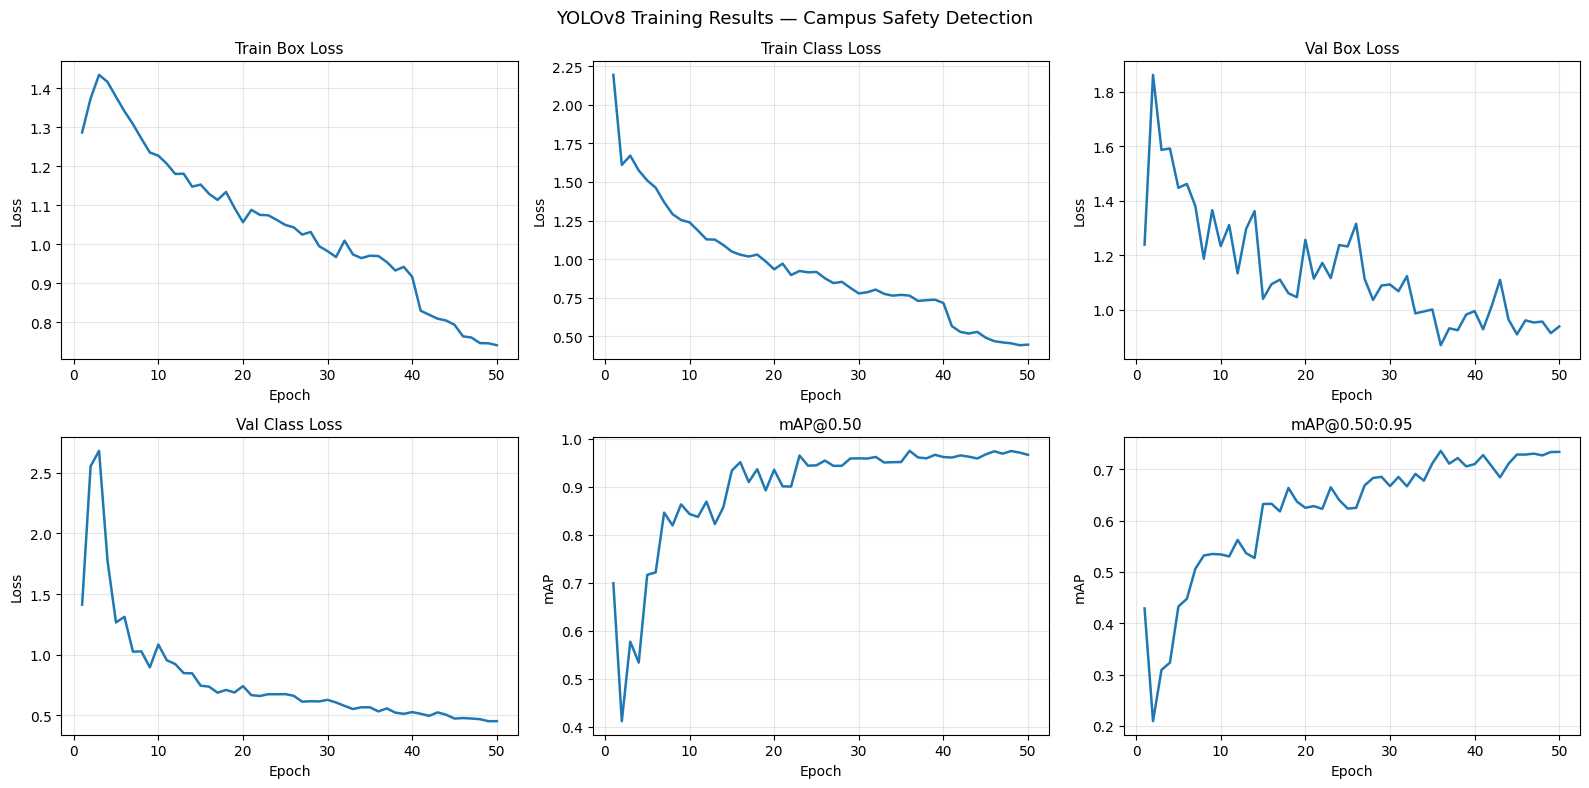

Saved training curves to: /content/BCS407_SafetyDetection/training_curves.png


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

results_csv = os.path.join(PROJECT_DIR, 'runs', 'detect', 'campus_safety_yolov8s', 'results.csv')
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('YOLOv8 Training Results — Campus Safety Detection', fontsize=13)

plots = [
    ('train/box_loss',   'Train Box Loss',   'Loss'),
    ('train/cls_loss',   'Train Class Loss', 'Loss'),
    ('val/box_loss',     'Val Box Loss',     'Loss'),
    ('val/cls_loss',     'Val Class Loss',   'Loss'),
    ('metrics/mAP50(B)', 'mAP@0.50',         'mAP'),
    ('metrics/mAP50-95(B)', 'mAP@0.50:0.95','mAP'),
]

for ax, (col, title, ylabel) in zip(axes.flatten(), plots):
    if col in df.columns:
        ax.plot(df['epoch'], df[col], linewidth=1.8)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved training curves to: {os.path.join(SAVE_DIR,'training_curves.png')}")

### 6c. Confusion Matrix

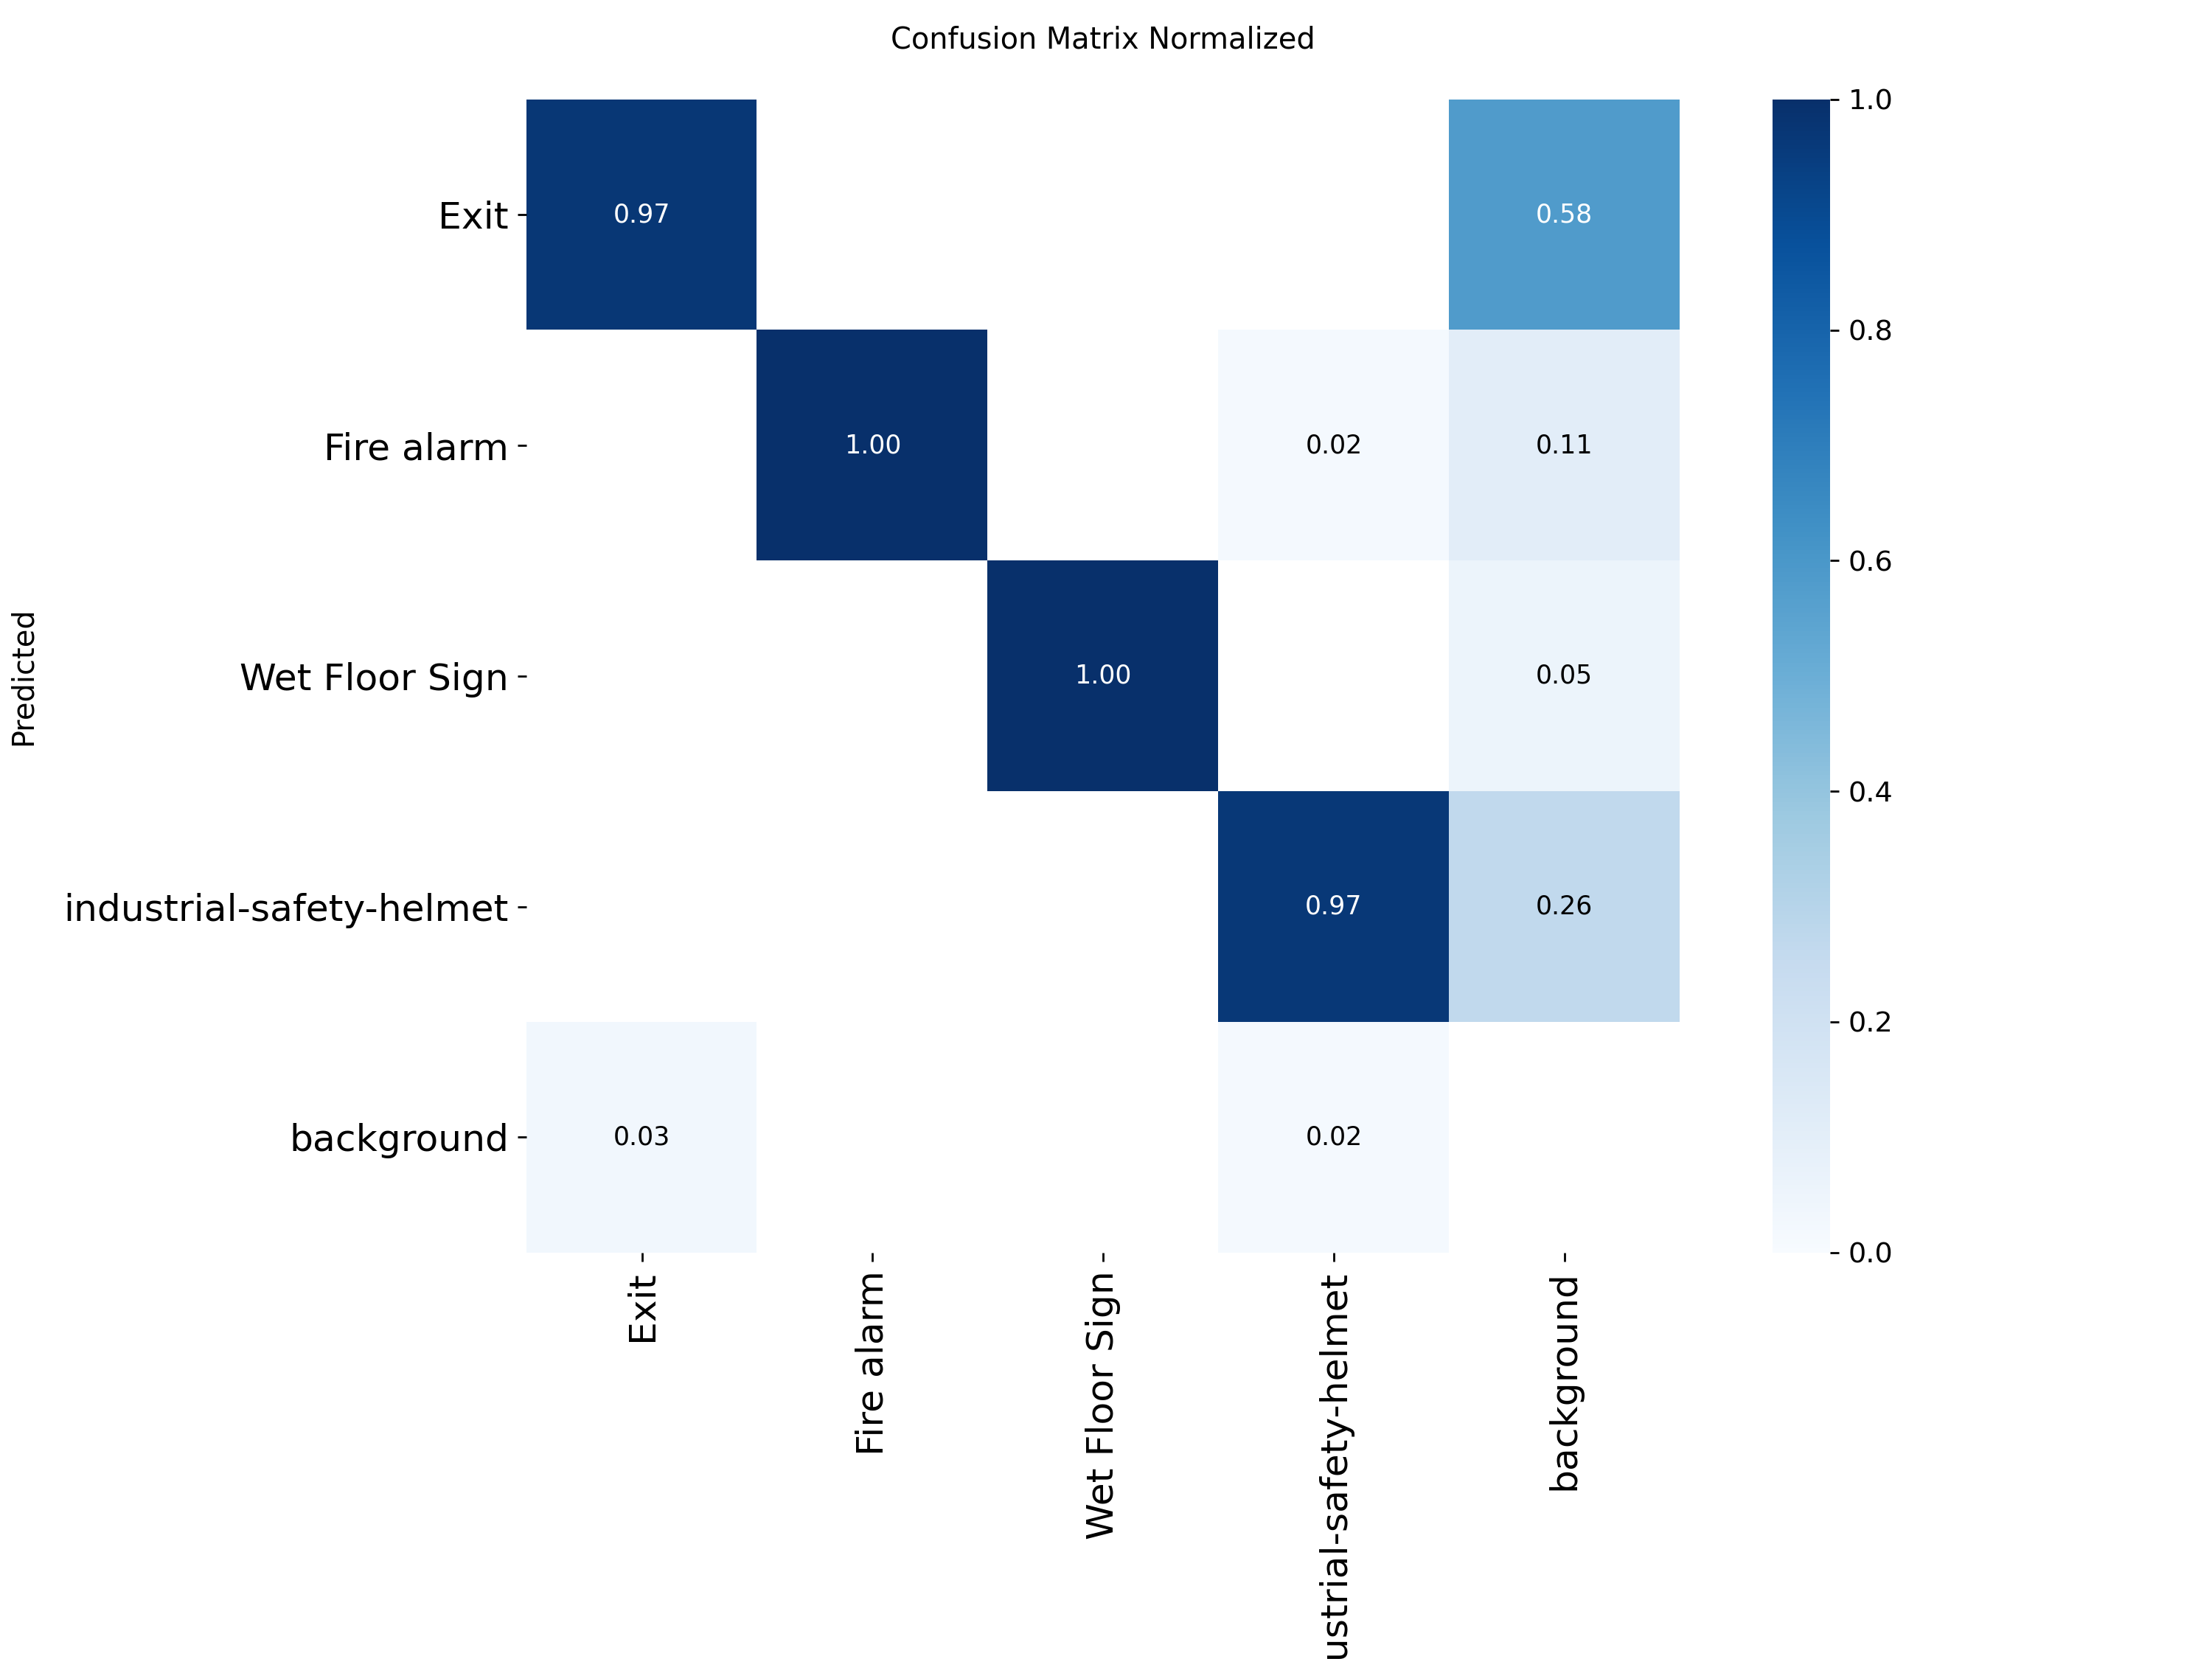

Confusion matrix copied to: /content/BCS407_SafetyDetection/confusion_matrix.png


In [18]:
from IPython.display import Image, display
import shutil

cm_path = os.path.join(PROJECT_DIR, 'runs', 'detect', 'campus_safety_yolov8s', 'confusion_matrix_normalized.png')
if os.path.exists(cm_path):
    display(Image(filename=cm_path))
    shutil.copy(cm_path, os.path.join(SAVE_DIR, 'confusion_matrix.png'))
    print(f"Confusion matrix copied to: {os.path.join(SAVE_DIR,'confusion_matrix.png')}")
else:
    print('Run validation with plots=True first (Step 6a).')

### 6d. PR Curve & F1 Curve

In [19]:
from IPython.display import Image, display
import shutil

val_dir = os.path.join(PROJECT_DIR, 'runs', 'detect', 'campus_safety_yolov8s')
for fname in ['PR_curve.png', 'F1_curve.png', 'P_curve.png', 'R_curve.png']:
    fpath = os.path.join(val_dir, fname)
    if os.path.exists(fpath):
        print(f'--- {fname} ---')
        display(Image(filename=fpath))
        shutil.copy(fpath, os.path.join(SAVE_DIR, fname))

## Step 7 — Run Inference (Live Prediction)
### 7a. Predict on test set

In [20]:
test_images_path = os.path.join(DATASET_PATH, 'test', 'images')

predictions = best_model.predict(
    source  = test_images_path,
    conf    = 0.25,
    iou     = 0.45,
    save    = True,
    save_txt= True,
    project = PROJECT_DIR,
    name    = 'predict_test',
    exist_ok= True,
    device  = DEVICE,
)

print(f'Predictions saved to: {os.path.join(PROJECT_DIR, "predict_test")}')


image 1/207 /content/BCS_407-Project-1/test/images/IMG_3056_jpg.rf.f0528d701da490f60e52e9f5bc0cef5f.jpg: 640x640 1 Fire alarm, 16.1ms
image 2/207 /content/BCS_407-Project-1/test/images/IMG_3064_jpg.rf.d7b803bd23e2378b36fb0b5f45bca64c.jpg: 640x640 1 Exit, 2 Fire alarms, 16.1ms
image 3/207 /content/BCS_407-Project-1/test/images/Is-Elbiseleri-Is-Ayakkabilari-Is-1-_jpg.rf.3f926b0b10bc3a761322fac520cd3bcd.jpg: 640x640 2 industrial-safety-helmets, 16.1ms
image 4/207 /content/BCS_407-Project-1/test/images/ML_20240205_10-21-51_jpg.rf.8f5f8847f1ec959a13253989b011c4ba.jpg: 640x640 1 Exit, 16.1ms
image 5/207 /content/BCS_407-Project-1/test/images/ML_20240205_10-24-07_jpg.rf.133bcabd9c4b4b6b650d789dd4bc252e.jpg: 640x640 1 Exit, 16.1ms
image 6/207 /content/BCS_407-Project-1/test/images/ML_20240205_10-41-42_jpg.rf.da1a917a154f6555de3637601efa0836.jpg: 640x640 (no detections), 16.1ms
image 7/207 /content/BCS_407-Project-1/test/images/ML_20240205_10-45-11_jpg.rf.f59429029082add632af1d4969239ee5.jpg: 

### 7b. Visualize predictions on sample test images

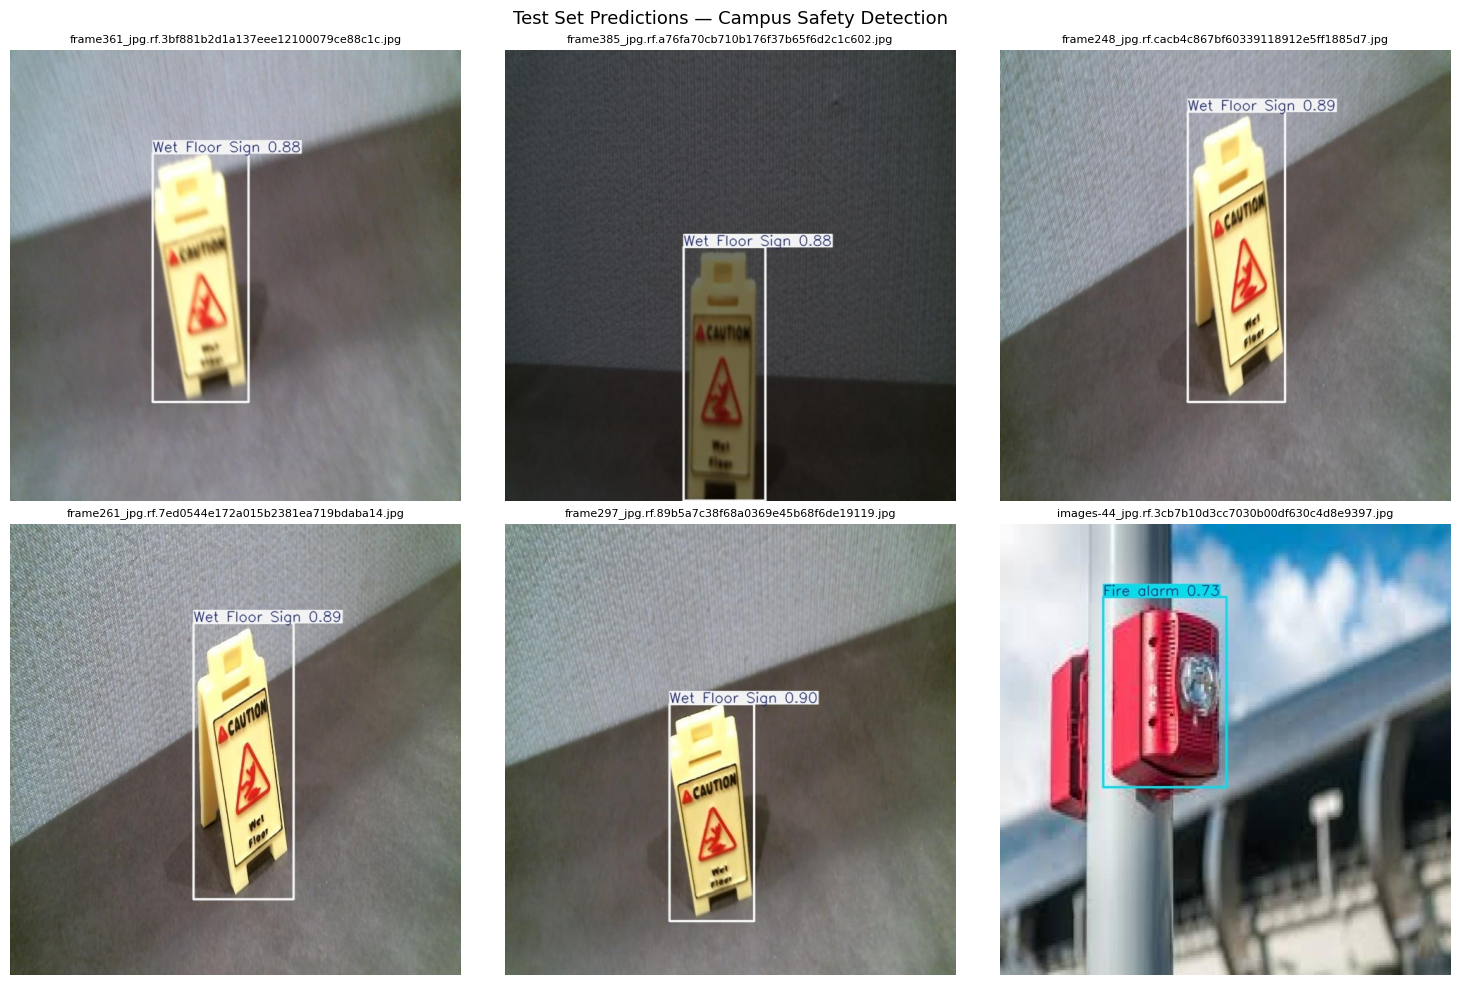

Saved sample predictions to: /content/BCS407_SafetyDetection/sample_predictions.png


In [21]:
import glob

pred_dir = os.path.join(PROJECT_DIR, 'runs', 'detect', 'predict_test')
pred_images = glob.glob(os.path.join(pred_dir, '*.jpg')) + glob.glob(os.path.join(pred_dir, '*.png'))

sample_preds = random.sample(pred_images, min(6, len(pred_images)))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Test Set Predictions — Campus Safety Detection', fontsize=13)

for ax, img_path in zip(axes.flatten(), sample_preds):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(os.path.basename(img_path), fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'sample_predictions.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved sample predictions to: {os.path.join(SAVE_DIR,'sample_predictions.png')}")

### 7c. Predict on a single image (for live demo / presentation)
> Upload an image using the file picker below. This simulates the **live inference verification** required in the presentation.

In [ ]:
# Use a local file picker for live inference (works on desktop)
'''
import tkinter as tk
from tkinter import filedialog
from PIL import Image as PILImage

root = tk.Tk()
root.withdraw()
filename = filedialog.askopenfilename(title='Select an image for live inference')
if not filename:
    print('No file selected.')
else:
    results_live = best_model.predict(
        source = filename,
        conf   = 0.25,
        iou    = 0.45,
        save   = True,
        project= PROJECT_DIR,
        name   = 'live_demo',
        exist_ok=True,
        device = DEVICE,
    )

    # Show the annotated output
    result = results_live[0]
    annotated = result.plot()
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8))
    plt.imshow(annotated_rgb)
    plt.axis('off')
    plt.title('Live Inference Result', fontsize=13)
    plt.tight_layout()
    out_path = os.path.join(SAVE_DIR, f'live_inference_{os.path.basename(filename)}')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Live inference saved to: {out_path}')

    # Print detections
    print('\nDetections:')
    print(f"{'Class':<25} {'Confidence':>12} {'Bounding Box'}")
    print('-'*70)
    for box in result.boxes:
        cls_id = int(box.cls.item())
        cls_name = best_model.names[cls_id]
        conf = box.conf.item()
        xyxy = box.xyxy[0].tolist()
        print(f"{cls_name:<25} {conf:>12.4f}  [{xyxy[0]:.0f},{xyxy[1]:.0f},{xyxy[2]:.0f},{xyxy[3]:.0f}]")

        '''


## Step 8 — Save Model Weights to Google Drive

In [22]:
import shutil

# Copy best and last weights
weights_src = os.path.join(PROJECT_DIR, 'runs', 'detect', 'campus_safety_yolov8s', 'weights')
weights_dst = os.path.join(SAVE_DIR, 'weights')
os.makedirs(weights_dst, exist_ok=True)

for wfile in ['best.pt', 'last.pt']:
    src = os.path.join(weights_src, wfile)
    if os.path.exists(src):
        shutil.copy(src, weights_dst)
        print(f'Saved {wfile} → {weights_dst}')

# Copy full training run
run_dst = os.path.join(SAVE_DIR, 'training_run')
if os.path.exists(run_dst):
    shutil.rmtree(run_dst)
shutil.copytree(os.path.join(PROJECT_DIR, 'runs', 'detect', 'campus_safety_yolov8s'), run_dst)
print(f'\nFull training run saved to: {run_dst}')

Saved best.pt → /content/BCS407_SafetyDetection/weights
Saved last.pt → /content/BCS407_SafetyDetection/weights

Full training run saved to: /content/BCS407_SafetyDetection/training_run


## Step 9 — Summary Report

In [23]:
print('='*55)
print('  BCS407 — TRAINING SUMMARY REPORT')
print('='*55)
print(f'  Model         : YOLOv8s')
print(f'  Dataset       : {DATASET_PATH}')
print(f'  Classes       : {class_names}')
print(f'  Epochs        : 50')
print(f'  Image size    : 640x640')
print()
print('  RESULTS (Validation Set):')
print(f'  mAP@0.50      : {metrics.box.map50:.4f}')
print(f'  mAP@0.50:0.95 : {metrics.box.map:.4f}')
print(f'  Precision     : {metrics.box.mp:.4f}')
print(f'  Recall        : {metrics.box.mr:.4f}')
print()
print('  FILES SAVED TO:')
print(f'  {SAVE_DIR}/')
print('    weights/best.pt')
print('    training_curves.png')
print('    confusion_matrix.png')
print('    sample_annotations.png')
print('    sample_predictions.png')
print('='*55)

  BCS407 — TRAINING SUMMARY REPORT
  Model         : YOLOv8s
  Dataset       : /content/BCS_407-Project-1
  Classes       : ['Exit', 'Fire alarm', 'Wet Floor Sign', 'industrial-safety-helmet']
  Epochs        : 50
  Image size    : 640x640

  RESULTS (Validation Set):
  mAP@0.50      : 0.9679
  mAP@0.50:0.95 : 0.7238
  Precision     : 0.9617
  Recall        : 0.9425

  FILES SAVED TO:
  /content/BCS407_SafetyDetection/
    weights/best.pt
    training_curves.png
    confusion_matrix.png
    sample_annotations.png
    sample_predictions.png
